### Визуализация сгенерированных масок мультиклассовой сегментации

In [7]:
import cv2
import random
import pickle
import matplotlib.pyplot as plt

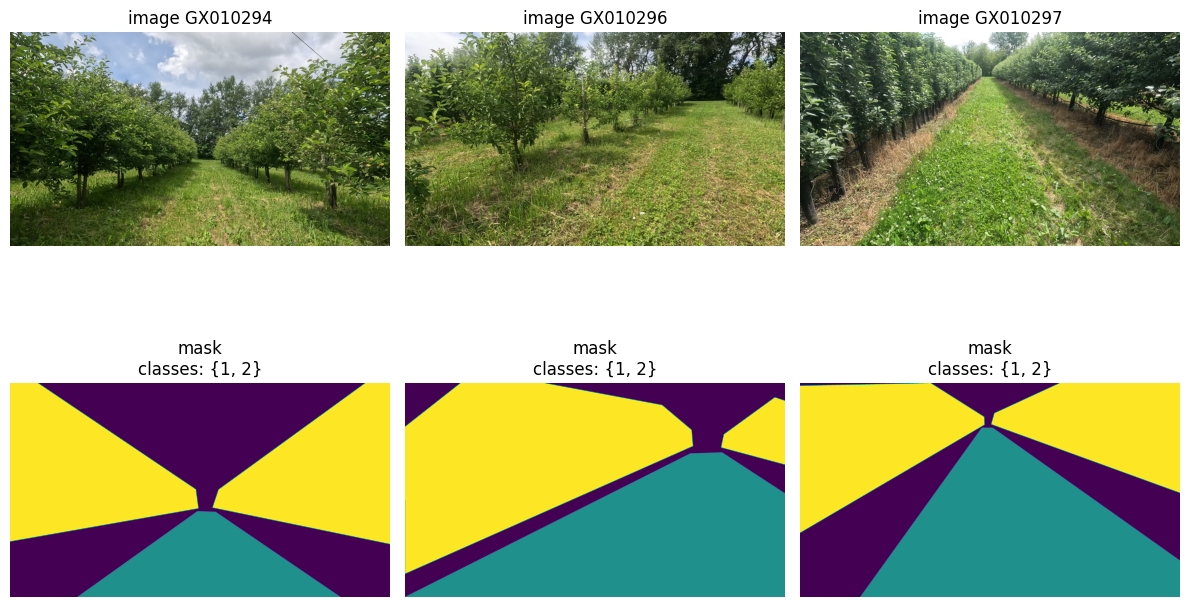

In [25]:
def visualize_masks(masks_info, num_examples=3):
    samples = random.sample(masks_info, min(num_examples, len(masks_info)))
    fig, axes = plt.subplots(2, len(samples), figsize=(4*len(samples), 8))
    
    for i, s in enumerate(samples):
        img = cv2.cvtColor(cv2.imread(f'../train/{s["file_name"]}'), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(f'../masks/{s["mask_name"]}', cv2.IMREAD_GRAYSCALE)
        
        axes[0, i].imshow(img)
        axes[0, i].set_title('image ' + s["file_name"].split('_')[0])
        axes[0, i].axis('off')
        
        axes[1, i].imshow(mask)
        axes[1, i].set_title(f'mask\nclasses: {set(s["classes"])}')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

with open('../masks/masks_info.pkl', 'rb') as f:
    masks_info = pickle.load(f)
    
visualize_masks(masks_info, 3)